In [46]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Basics

In [47]:
import numpy as np
import torch
import scanpy as sc
import matplotlib.pyplot as plt
import functools
import pandas as pd
import ot as pot
import warnings
import os
import dcor

from sc_flow import SCFlow
from sc_flow.backends.torch.coupling import ot_linear_coupling
from sc_flow.backends.torch._utils import to_torch_tensor
from sc_flow.data.samplers._train import MultiTransitionSampler
from sc_flow.backends.torch.metrics import MaximumMeanDiscrepancy
from sc_flow.backends.torch.probability_paths import LinearGaussianProbabilityPath

SEED = 44
np.random.seed(SEED)
torch.manual_seed(SEED)
prng = torch.Generator().manual_seed(SEED)
warnings.filterwarnings("ignore")

In [48]:
DATA_PATH = r"400_data/GSE232025_stereoseq_g_10000_nzp_0.1.h5ad"
STAGES_ALL = ["Stage44", "Stage54", "Stage57", "Juvenile", "Adult"]
STAGE_TIMES = {"Stage44": 0, "Stage54": 1, "Stage57": 2, "Juvenile": 3, "Adult": 4}
N_PCA = 50
N_SS = 50
CTF_H_EPS = 100        # relative_default: entropy_reg = 100
CTF_H_LAMBDA = 0.4     # relative_default: OT_reg_lambda = 0.4
CTF_H_NITER = 1000     # match POT default used by ContextFlow

In [49]:
adata = sc.read_h5ad(DATA_PATH)

X_pca = adata.obsm["X_pca"].astype(np.float32)
ss_context = adata.obsm["local_mean_X_pca"].astype(np.float32)
lr_pattern = adata.obsm["LR_pattern"].astype(np.float32)

adata.obsm["X_state_ctx"] = np.concatenate([X_pca, ss_context, lr_pattern], axis=1)
adata.uns["stage_emb"] = {s: np.array([t], dtype=np.float32) for s, t in STAGE_TIMES.items()}
adata.obs["day"] = adata.obs["day"].astype(int).map(dict(enumerate(STAGES_ALL)))
print(f"X_pca shape:        {X_pca.shape}")
print(f"ss_context shape:   {ss_context.shape}")
print(f"lr_pattern shape:   {lr_pattern.shape}")
print(f"X_state_ctx shape:  {adata.obsm['X_state_ctx'].shape}")

X_pca shape:        (28757, 50)
ss_context shape:   (28757, 50)
lr_pattern shape:   (28757, 233)
X_state_ctx shape:  (28757, 333)


# Functions

In [50]:
def _sample_from_coupling(Pi: np.ndarray, n_samples: int):
    """Sample index pairs proportional to coupling matrix Pi."""
    Pi_flat = Pi.ravel()
    Pi_flat = np.nan_to_num(Pi_flat, nan=0.0, posinf=0.0, neginf=0.0)
    Pi_flat = np.clip(Pi_flat, 0, None)  # numerical safety
    total = Pi_flat.sum()
    if total < 1e-10:
        Pi_flat = np.ones_like(Pi_flat)  # fallback to uniform
        total = Pi_flat.sum()
    Pi_flat = Pi_flat / total
    choices = np.random.choice(
        Pi.shape[0] * Pi.shape[1],
        size=n_samples,
        p=Pi_flat,
        replace=False,
    )
    src_idx, tgt_idx = np.divmod(choices, Pi.shape[1])
    return src_idx, tgt_idx

In [51]:
def ctf_h_coupling(
    source_lin,
    target_lin,
    source_quad=None,
    target_quad=None,
    eps: float = 0.1,
    lam: float = 0.5,
    n_iter: int = 100,
    **kwargs,
):
    """CTF-H: Sinkhorn OT with prior-biased Gibbs kernel K = M_hat * exp(-C/eps)."""
    # -- 1. Split source_lin / target_lin  --------------------------------
    src_pca = source_lin[:, :N_PCA]
    src_ss = source_lin[:, N_PCA : N_PCA + N_SS]
    src_lr = source_lin[:, N_PCA + N_SS :]

    tgt_pca = target_lin[:, :N_PCA]
    tgt_ss = target_lin[:, N_PCA : N_PCA + N_SS]
    tgt_lr = target_lin[:, N_PCA + N_SS :]

    # -- 2. Cost matrix C (PCA distance, scaled for numerical stability) --
    src_t = to_torch_tensor(src_pca).float()
    tgt_t = to_torch_tensor(tgt_pca).float()
    C = torch.cdist(src_t, tgt_t) ** 2
    #C = C / (C.mean() + 1e-10) # Normalize is False in ContextFlow

    # -- 3. Prior matrix M_hat from SS + LR context -----------------------
    src_ss_t = to_torch_tensor(src_ss).float()
    tgt_ss_t = to_torch_tensor(tgt_ss).float()

    src_lr_t = to_torch_tensor(src_lr).float()
    tgt_lr_t = to_torch_tensor(tgt_lr).float()

    # Transitional Plausibility Matrix (TPM): high = implausible transition
    SS_diss = torch.cdist(src_ss_t, tgt_ss_t) ** 2
    LR_diss = torch.cdist(src_lr_t, tgt_lr_t) ** 2

    SS_diss = SS_diss / (SS_diss.max() + 1e-10)
    LR_diss = LR_diss / (LR_diss.max() + 1e-10)

    M = lam * SS_diss + (1 - lam) * LR_diss

    # Row-normalise: low M[i,j] -> high M_hat[i,j] (plausible pair)
    M_hat = torch.softmax(-M, dim=1)  # (n_src, n_tgt)

    # -- 4. Effective cost: C_eff = C - eps * log(M_hat) ------------------
    C_np = C.detach().cpu().numpy().astype(np.float64)
    M_np = M_hat.detach().cpu().numpy().astype(np.float64)
    C_eff = C_np - eps * np.log(M_np + 1e-300)

    # Normalize C_eff to prevent exp(-C/eps) overflow in standard Sinkhorn
    C_eff = C_eff / (C_eff.max() + 1e-10)

    n_src, n_tgt = C_eff.shape
    a = pot.unif(n_src)
    b = pot.unif(n_tgt)

    # -- 5. POT sinkhorn (stable at small eps) ----------------------------
    Pi = pot.sinkhorn(
        a,
        b,
        C_eff,
        reg=eps,
        # method="sinkhorn_log",
        numItermax=n_iter,
    )

    # -- 6. Sample index pairs from transport plan -------------------------
    return _sample_from_coupling(Pi, n_samples=n_src)

In [52]:
def run(
    MATCHED_KEYS,
    eps,
    lam,
    n_iter,
    hidden_dims,
    activation,
    epoch,
    batch_size,
    lr,
    probability_path,
    encode_state,
    encode_time,
):
    """Run model"""
    SCFlow.register_adata(
        adata,
        sample_rep="X_pca",
        coupling_rep="X_state_ctx",
        conditions={"day": ["day"]},
        conditions_reps={"day": "stage_emb"},
        matched_keys=MATCHED_KEYS,
    )

    ctf_h_partial = functools.partial(
        ctf_h_coupling,
        eps=eps,
        lam=lam,
        n_iter=n_iter,
    )

    model = SCFlow(
        method_id="cfm",
        backend="torch",
        match_fn=ctf_h_partial,
        vf_decoder_mlp_kwargs={"hidden_dims": hidden_dims, "activation_cls": activation},
        encode_state=encode_state,
        encode_time=encode_time,
        probability_path=probability_path,
    )

    model.train(
        adata,
        callbacks=None,
        sort=True,
        n_train_steps=epoch,
        train_batch_size=batch_size,
        train_sampler=MultiTransitionSampler,
        optim_kwargs={"lr": lr},
        timepoints=[0, 1, 2, 3],
    )

    return model

In [53]:
def predict(model, solver, PRED_KEYS, T_START_PRED, T_END_PRED):
    """Predict with trained model"""
    preds_extra = {}
    for (src, tgt), ts, te in zip(PRED_KEYS, T_START_PRED, T_END_PRED, strict=False):
        result = model.predict(
            adata,
            solver_kwargs={"method": solver},
            sort=True,
            matched_keys={(src,): (tgt,)},
            return_trajectory=True,
            num_steps=400,
            t_start=ts,
            t_end=te,
        )
        preds_extra[(src, tgt)] = np.array(result.X)

    return preds_extra

In [54]:
def predict_ivp(model, transitions_ordered, t_start=0.0, t_end=4.0, num_steps=401):
    """Single ODE solve from t_start to t_end; slices trajectory at each integer transition boundary."""
    transitions_ordered = list(transitions_ordered)
    src_stage = transitions_ordered[0][0]
    tgt_stage = transitions_ordered[-1][1]

    result = model.predict(
        adata,
        sort=True,
        matched_keys={(src_stage,): (tgt_stage,)},
        return_trajectory=True,
        num_steps=num_steps,
        t_start=t_start,
        t_end=t_end,
    )

    # result.obsm["trajectory"]: (n_cells, num_steps, features)
    traj = result.obsm["trajectory"]

    preds = {}
    for i, (src, tgt) in enumerate(transitions_ordered):
        t_boundary = t_start + i + 1
        idx = round((t_boundary - t_start) / (t_end - t_start) * (num_steps - 1))
        preds[(src, tgt)] = traj[:, idx, :]

    return preds

In [55]:
def compute_w2(X, Y):
    """Compute sliced 2-Wasserstein distance between X and Y."""
    rng = np.random.RandomState(SEED)
    Xi = X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)].astype(np.float64)
    Yi = Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)].astype(np.float64)
    return float(pot.sliced.sliced_wasserstein_distance(Xi, Yi, n_projections=200, p=2, seed=SEED))


def compute_mmd(X, Y):
    """Compute MMD between X and Y."""
    rng = np.random.RandomState(SEED)
    Xi = torch.tensor(X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)]).float()
    Yi = torch.tensor(Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)]).float()
    m = MaximumMeanDiscrepancy()
    m.update(Xi, Yi)
    return float(m.compute())


def compute_energy(X, Y):
    """Compute energy distance between X and Y (unbiased, matches contextflow)."""
    rng = np.random.RandomState(SEED)
    Xi = X[rng.choice(X.shape[0], min(N_EVAL, X.shape[0]), replace=False)]
    Yi = Y[rng.choice(Y.shape[0], min(N_EVAL, Y.shape[0]), replace=False)]
    return float(dcor.energy_distance(Xi, Yi))


def compute_metrics(preds_extra, adata):
    """Compute all metrics and plot a line graph of model (solid) vs baseline (dashed)."""
    rows = []
    ordered_keys = sorted(preds_extra.keys(), key=lambda x: STAGES_ALL.index(x[0]))
    for src, tgt in ordered_keys:
        pred = preds_extra[(src, tgt)]
        true_tgt = adata[adata.obs["day"] == tgt].obsm["X_pca"].astype(np.float32)
        src_cells = adata[adata.obs["day"] == src].obsm["X_pca"].astype(np.float32)

        rows.append(
            {
                "transition": f"{src} -> {tgt}",
                "W2 (model)": compute_w2(pred, true_tgt),
                "W2 (baseline)": compute_w2(src_cells, true_tgt),
                "MMD (model)": compute_mmd(pred, true_tgt),
                "MMD (baseline)": compute_mmd(src_cells, true_tgt),
                "Energy (model)": compute_energy(pred, true_tgt),
                "Energy (baseline)": compute_energy(src_cells, true_tgt),
            }
        )

    df = pd.DataFrame(rows).set_index("transition").round(4)

    metrics = [("W2", "#1f77b4"), ("MMD", "#ff7f0e"), ("Energy", "#2ca02c")]
    x = np.arange(len(df))
    x_labels = df.index.tolist()

    fig, ax = plt.subplots(figsize=(10, 4))
    for name, color in metrics:
        ax.plot(
            x, df[f"{name} (model)"].values, color=color, linestyle="-", linewidth=2, marker="o", label=f"{name} model"
        )
        ax.plot(
            x,
            df[f"{name} (baseline)"].values,
            color=color,
            linestyle="--",
            linewidth=1.5,
            marker="o",
            label=f"{name} baseline",
        )
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=15, ha="right")
    ax.set_ylabel("Metric value")
    ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    return df

In [56]:
def plot_transitions(adata, transitions, preds_dict, title=None):
    """Plot each transition in a separate subplot."""
    fig, axes = plt.subplots(1, len(transitions), figsize=(6 * len(transitions), 5))
    if len(transitions) == 1:
        axes = [axes]

    X_pca_all = adata.obsm["X_pca"]
    for ax, (src, tgt) in zip(axes, transitions, strict=False):
        src_mask = adata.obs["day"].values == src
        tgt_mask = adata.obs["day"].values == tgt
        X_pred = preds_dict[(src, tgt)]

        ax.scatter(X_pca_all[src_mask, 0], X_pca_all[src_mask, 1], s=2, alpha=0.15, color="steelblue", label=src)
        ax.scatter(X_pred[:, 0], X_pred[:, 1], s=5, alpha=0.7, color="tomato", label="Predicted")
        ax.scatter(X_pca_all[tgt_mask, 0], X_pca_all[tgt_mask, 1], s=2, alpha=0.5, color="seagreen", label=tgt)
        ax.set_title(f"{src} → {tgt}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(loc="upper right", markerscale=2, frameon=False)

    if title:
        plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

# Runs

## Extrapolation

In [57]:
hidden_dims = (10, 10, 10)
activation = torch.nn.SELU
encode_state = False
encode_time = False
epoch = 10_000
lr = 1e-4
batch_size = 256
probability_path = LinearGaussianProbabilityPath(sigma=0.9, prng=prng)
N_EVAL = 1500
solver = "dopri5"

matched_keys_extra = {
    ("Stage44",): ("Stage54",),
    ("Stage54",): ("Stage57",),
    ("Stage57",): ("Juvenile",),
}

transitions = [
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
]

t_start_pred = [0, 1, 2, 3]
t_end_pred = [1, 2, 3, 4]

In [58]:
model = run(
    MATCHED_KEYS=matched_keys_extra,
    eps=CTF_H_EPS,
    lam=CTF_H_LAMBDA,
    n_iter=CTF_H_NITER,
    hidden_dims=hidden_dims,
    activation=activation,
    epoch=epoch,
    batch_size=batch_size,
    lr=lr,
    probability_path=probability_path,
    encode_state=encode_state,
    encode_time=encode_time,
)

  0%|          | 0/3 [00:00<?, ?it/s]

| loss:9.9783 | step:9999: 100%|██████████| 10000/10000 [12:07<00:00, 13.75it/s]


### Next-Step

In [59]:
ns_pred = predict(model, solver=solver, PRED_KEYS=transitions, T_START_PRED=t_start_pred, T_END_PRED=t_end_pred)

  0%|          | 0/1 [00:00<?, ?it/s]

Predicting: 100%|██████████| 1/1 [00:01<00:00,  1.66s/it]


  0%|          | 0/1 [00:00<?, ?it/s]



Predicting: 100%|██████████| 1/1 [00:01<00:00,  1.97s/it]


  0%|          | 0/1 [00:00<?, ?it/s]





Predicting: 100%|██████████| 1/1 [00:02<00:00,  2.87s/it]


  0%|          | 0/1 [00:00<?, ?it/s]







Predicting: 100%|██████████| 1/1 [00:01<00:00,  1.95s/it]


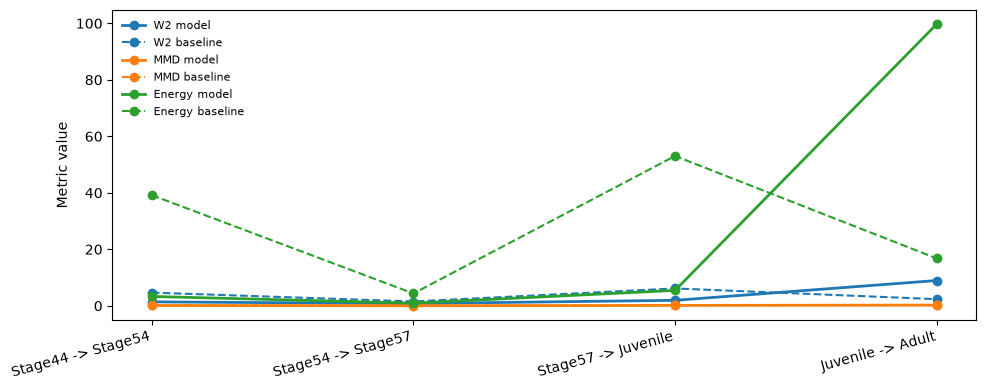

,W2 (model),W2 (baseline),MMD (model),MMD (baseline),Energy (model),Energy (baseline)
transition,,,,,,
Stage44 -> Stage54,1.3889,4.6730,0.1102,0.2457,3.3108,39.1768
Stage54 -> Stage57,0.7981,1.5189,0.0117,0.0274,0.9412,4.3635
Stage57 -> Juvenile,1.9391,6.1394,0.1424,0.2055,5.4548,53.0351
Juvenile -> Adult,8.9488,2.3504,0.2516,0.2069,99.7235,16.7737


In [60]:
metrics = compute_metrics(ns_pred, adata)
metrics

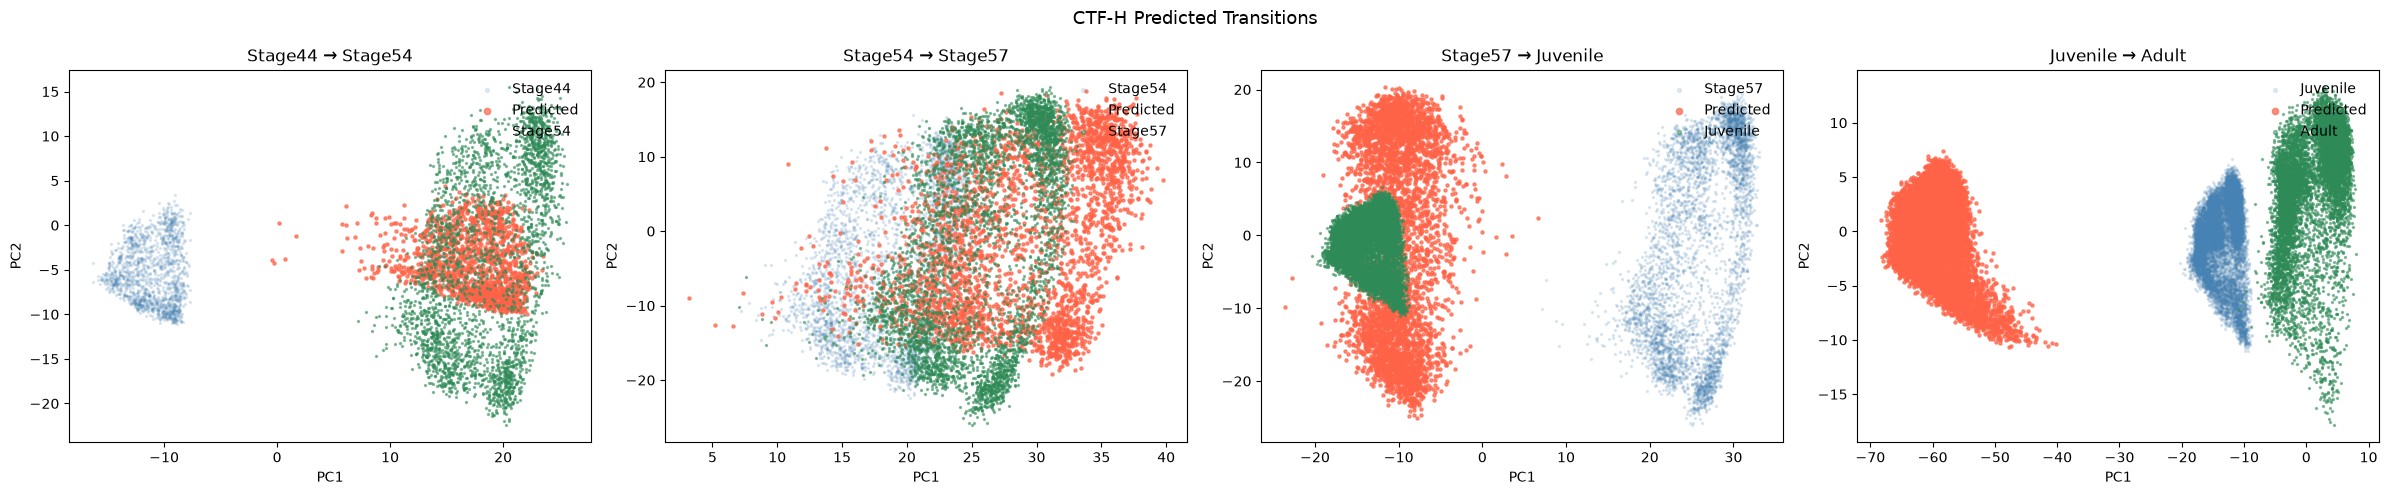

In [61]:
plot_transitions(adata, transitions, ns_pred, title="CTF-H Predicted Transitions")

### IVP

In [62]:
ns_pred = predict_ivp(
    model,
    transitions,
)

  0%|          | 0/1 [00:00<?, ?it/s]

Predicting: 100%|██████████| 1/1 [00:00<00:00,  1.36it/s]


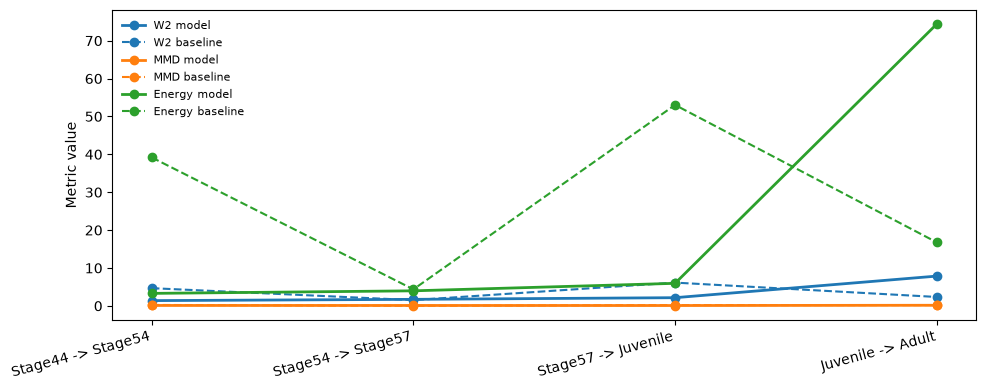

,W2 (model),W2 (baseline),MMD (model),MMD (baseline),Energy (model),Energy (baseline)
transition,,,,,,
Stage44 -> Stage54,1.3867,4.6730,0.1100,0.2457,3.2958,39.1768
Stage54 -> Stage57,1.7238,1.5189,0.1066,0.0274,3.9708,4.3635
Stage57 -> Juvenile,2.1590,6.1394,0.0903,0.2055,5.9503,53.0351
Juvenile -> Adult,7.8583,2.3504,0.1595,0.2069,74.3801,16.7737


In [63]:
metrics = compute_metrics(ns_pred, adata)
metrics

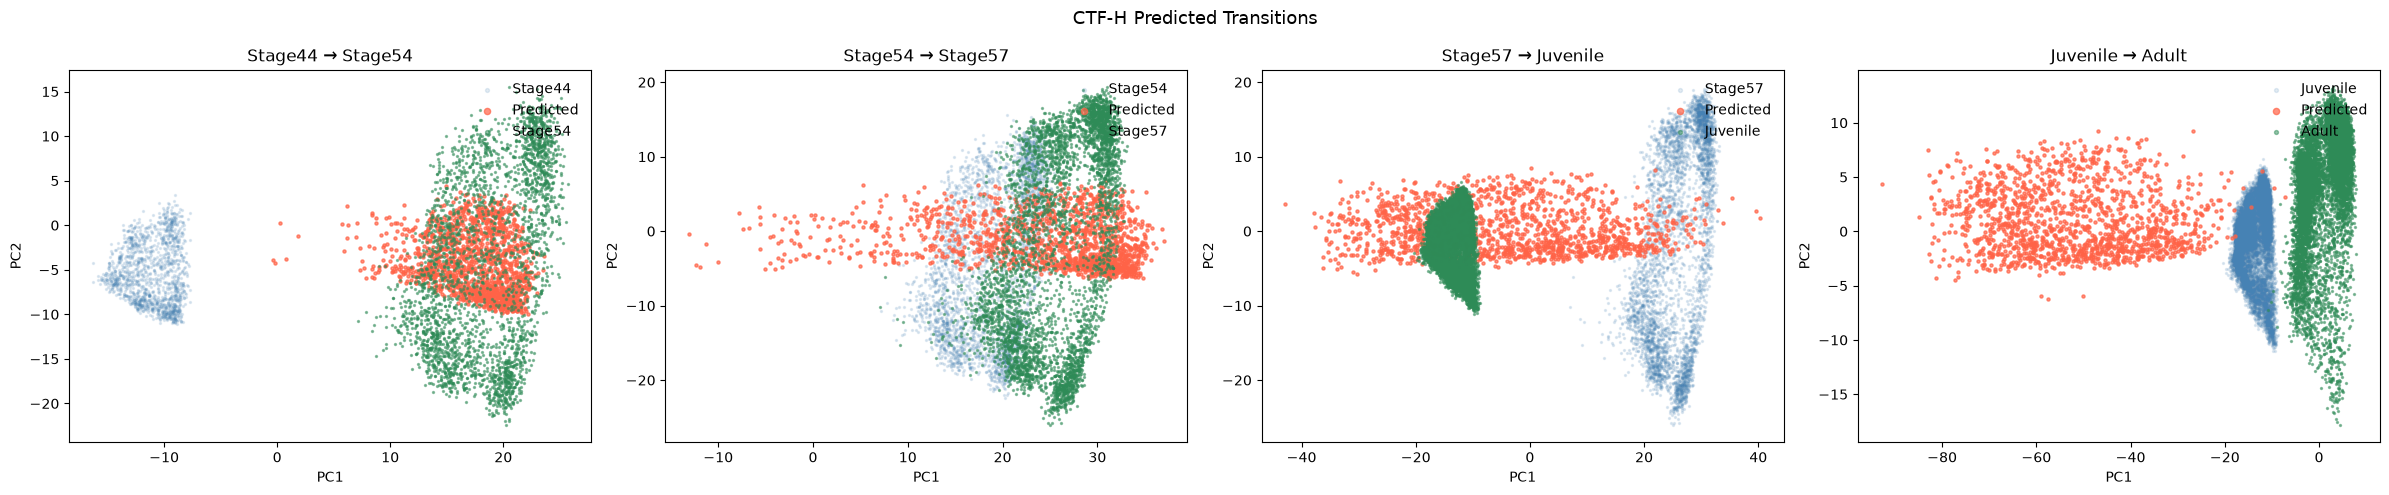

In [64]:
plot_transitions(adata, transitions, ns_pred, title="CTF-H Predicted Transitions")

## Interpolation

In [65]:
matched_keys = {
    ("Stage44",): ("Stage54",),
    ("Stage54",): ("Stage57",),
    ("Stage57",): ("Adult",),
}

transitions = [
    ("Stage44", "Stage54"),
    ("Stage54", "Stage57"),
    ("Stage57", "Juvenile"),
    ("Juvenile", "Adult"),
]

t_start_pred = [0, 1, 2, 3]
t_end_pred = [1, 2, 3, 4]

In [66]:
model = run(
    MATCHED_KEYS=matched_keys,
    eps=CTF_H_EPS,
    lam=CTF_H_LAMBDA,
    n_iter=CTF_H_NITER,
    hidden_dims=hidden_dims,
    activation=activation,
    epoch=epoch,
    batch_size=batch_size,
    lr=lr,
    probability_path=probability_path,
    encode_state=encode_state,
    encode_time=encode_time,
)

  0%|          | 0/3 [00:00<?, ?it/s]

| loss:9.9558 | step:9999: 100%|██████████| 10000/10000 [12:04<00:00, 13.81it/s]


### Next Step

In [67]:
ns_pred = predict(model, solver=solver, PRED_KEYS=transitions, T_START_PRED=t_start_pred, T_END_PRED=t_end_pred)

  0%|          | 0/1 [00:00<?, ?it/s]

Predicting: 100%|██████████| 1/1 [00:01<00:00,  1.59s/it]


  0%|          | 0/1 [00:00<?, ?it/s]



Predicting: 100%|██████████| 1/1 [00:02<00:00,  2.53s/it]


  0%|          | 0/1 [00:00<?, ?it/s]





Predicting: 100%|██████████| 1/1 [00:02<00:00,  2.72s/it]


  0%|          | 0/1 [00:00<?, ?it/s]







Predicting: 100%|██████████| 1/1 [00:02<00:00,  2.94s/it]


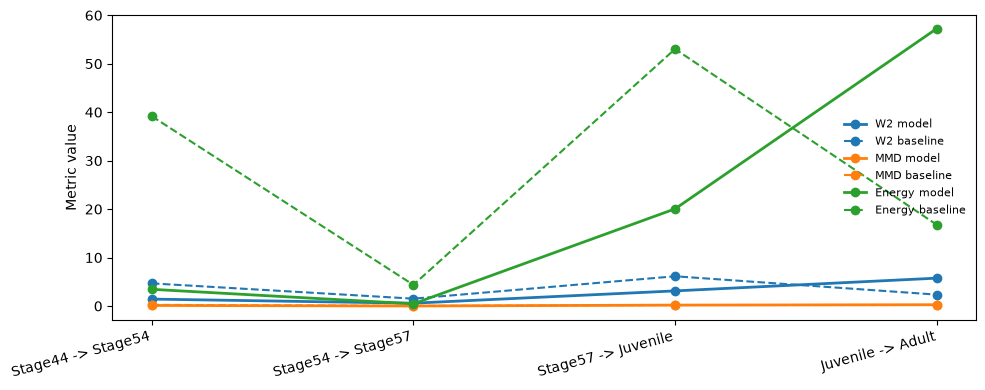

,W2 (model),W2 (baseline),MMD (model),MMD (baseline),Energy (model),Energy (baseline)
transition,,,,,,
Stage44 -> Stage54,1.4295,4.6730,0.1161,0.2457,3.4498,39.1768
Stage54 -> Stage57,0.5845,1.5189,0.0084,0.0274,0.4564,4.3635
Stage57 -> Juvenile,3.1227,6.1394,0.1875,0.2055,20.0501,53.0351
Juvenile -> Adult,5.7531,2.3504,0.2674,0.2069,57.2439,16.7737


In [68]:
metrics = compute_metrics(ns_pred, adata)
metrics

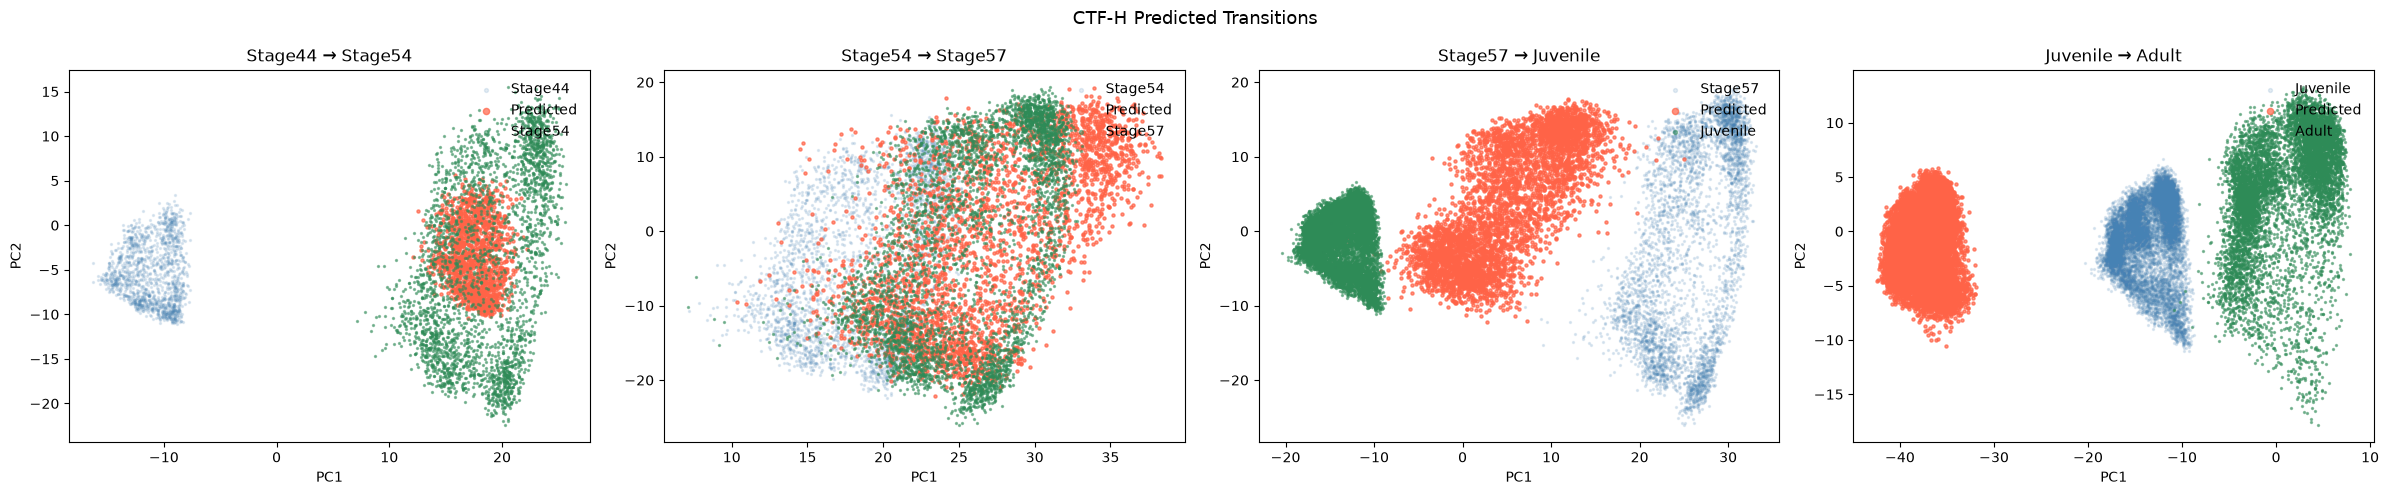

In [69]:
plot_transitions(adata, transitions, ns_pred, title="CTF-H Predicted Transitions")

### IVP

In [70]:
ns_pred = predict_ivp(
    model,
    transitions,
)

  0%|          | 0/1 [00:00<?, ?it/s]

Predicting: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]


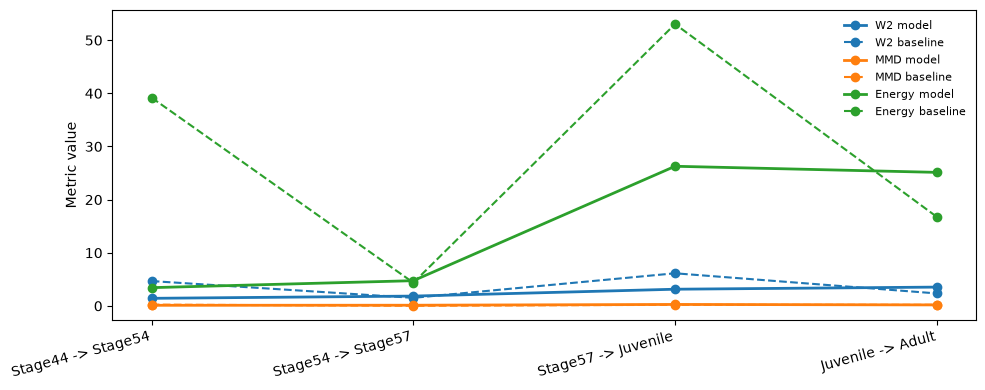

,W2 (model),W2 (baseline),MMD (model),MMD (baseline),Energy (model),Energy (baseline)
transition,,,,,,
Stage44 -> Stage54,1.4279,4.6730,0.1159,0.2457,3.4366,39.1768
Stage54 -> Stage57,1.8499,1.5189,0.1299,0.0274,4.7481,4.3635
Stage57 -> Juvenile,3.1414,6.1394,0.2762,0.2055,26.2793,53.0351
Juvenile -> Adult,3.5405,2.3504,0.1889,0.2069,25.1305,16.7737


In [71]:
metrics = compute_metrics(ns_pred, adata)
metrics

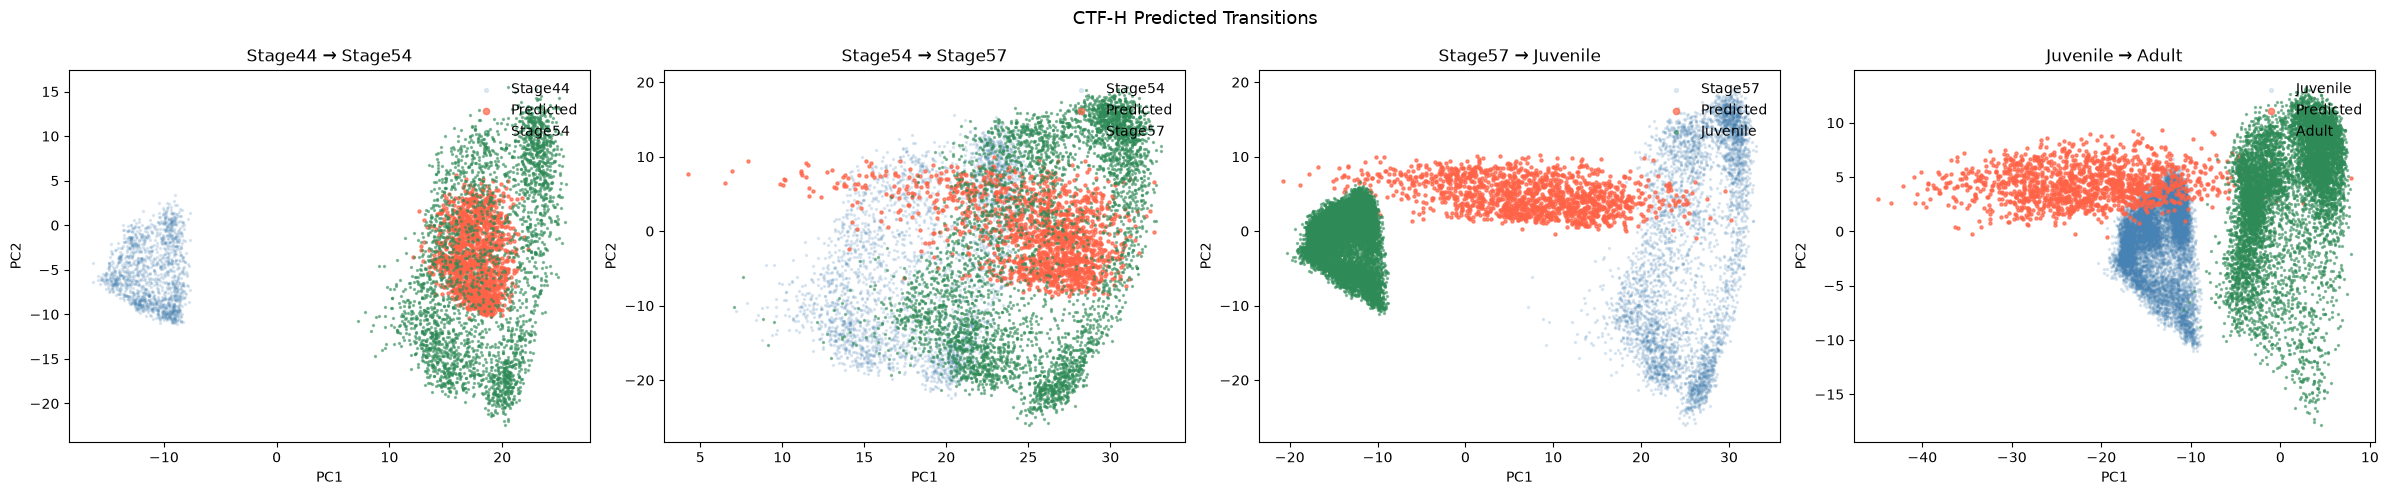

In [72]:
plot_transitions(adata, transitions, ns_pred, title="CTF-H Predicted Transitions")